In [ ]:
import sys

sys.path.append("../")
sys.path.append("../../")
sys.path.append("../../../")

import itertools
import os
from pathlib import Path

import matplotlib as mpl
from dotenv import load_dotenv

from tcr_toolbox.utils.plot_utils import plot_count_histogram, set_mpl_params

load_dotenv()
tcr_toolbox_data_path = os.getenv("tcr_toolbox_data_path")

from tcr_toolbox.sequencing_analysis_PRIVATE.plate_tcr_epi_count_analysis import (
    add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col,
    calculate_tcr_epi_pair_exp_prob_matrix,
    filter_UMI_counts_df_dict,
    init_umi_count_analysis_dir,
    obs_tcr_epi_count_binom_sf_test,
    plot_detected_tcr_epi_plate_map,
    plot_pvalue_corrected_rank_vs_pvalue_corrected,
    plot_tcr_epi_pair_ma_plot,
    read_tcr_epi_pair_counts_csv,
    read_umi_count_tsv,
    write_reactive_pair_results,
    write_tcr_epi_pair_well_count_files,
    add_pair_entropy_over_plate_col
)
from tcr_toolbox.sequencing_analysis.utils import overlap_between_ref_and_count_names, read_gdna_counts_csv
from tcr_toolbox.utils.plot_utils import startfig
from tcr_toolbox.utils.stat_utils import normalize_counts_df_by_total_counts

mpl, mylines = set_mpl_params(mpl=mpl)

In [ ]:
project_dir = Path("/data/mel-pt-b_nsclc-pt-c")
init_umi_count_analysis_dir(project_dir)

## NSCLC-Pt-C PAIR-Scan analysis

### NSCLC-Pt-C bulk seq analysis

In [ ]:
bulk_project_dir = project_dir / "bulk_seq_data" / "epi" 
name_split_location = 2

In [ ]:
for count_file in (bulk_project_dir / "counts").glob("*.csv"):
    print(count_file.name)
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file="/references/mel-pt-b_nsclc-pt-c_epi.fa",
        library_ref_id_list=["NSCLC-Pt-C"],
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True, 
        xlabel="Number of reads per transcript",
        percentile_ratio_filter_threshold = 1, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=75,
        w=6.25,
        h=6.25,
    )
    print("\n")

In [ ]:
bulk_project_dir = project_dir / "bulk_seq_data" / "tcr" 
name_split_location = 2

In [ ]:
for count_file in (bulk_project_dir / "counts").glob("*.csv"):
    print(count_file.name)
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file="/references/mel-pt-b_nsclc-pt-c_beta.fa",
        library_ref_id_list=["NSCLC-Pt-C"],
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True, 
        xlabel="Number of reads per transcript",
        percentile_ratio_filter_threshold = 1.25, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=50,
        w=6.25,
        h=6.25,
    )
    print("\n")

### NSCLC-Pt-C PAIR-Scan analysis

In [4]:
counts_df_dict = read_umi_count_tsv(project_dir=project_dir, plate_name_split_location=2)

Reading plate: 23
Reading plate: 21
Reading plate: 24
Reading plate: 26
Reading plate: 22
Reading plate: 25
Reading plate: 28
Reading plate: 27


In [5]:
epi_umi_threshold_dict = {
    "21": 200, 
    "22": 200, 
    "23": 200, 
    "24": 200, 
    "25": 200, 
    "26": 200, 
    "27": 200, 
    "28": 200, 

}

tcr_umi_threshold_dict = {
    "21": 40, 
    "22": 30,  
    "23": 20, 
    "24": 25, 
    "25": 20, 
    "26": 20, 
    "27": 30, 
    "28": 70

}

In [ ]:
counts_df_dict = filter_UMI_counts_df_dict(
    project_dir = project_dir, 
    counts_df_dict = counts_df_dict, 
    epi_umi_threshold=epi_umi_threshold_dict, 
    tcr_umi_threshold=tcr_umi_threshold_dict,
    min_start_fraction_of_top_umi_count=1.5,
    min_end_fraction_of_top_umi_count = 0.13,
    num_bins=50
)

Filtering plate: 23
Number of unique epis: 60
Number of unique tcrs: 178
Filtering plate: 21
Number of unique epis: 60
Number of unique tcrs: 151
Filtering plate: 24
Number of unique epis: 65
Number of unique tcrs: 158
Filtering plate: 26
Number of unique epis: 65
Number of unique tcrs: 174
Filtering plate: 22
Number of unique epis: 61
Number of unique tcrs: 166
Filtering plate: 25
Number of unique epis: 76
Number of unique tcrs: 170
Filtering plate: 28
Number of unique epis: 43
Number of unique tcrs: 61
Filtering plate: 27
Number of unique epis: 60
Number of unique tcrs: 153


In [ ]:
plates_list = ["21", "22", "23", "24", "25", "26", "27", "28"]

write_tcr_epi_pair_well_count_files(
    project_dir=project_dir,
    plates_list=plates_list,
    plates_list_name="nsclc-pt-c",
    counts_df_dict=counts_df_dict.copy(),
    collapse_epitope_barcode=True,
    epitope_barcode_length=18,
    validating_pair_dict=None,
)

Processing plate: 21
Processing plate: 22
Processing plate: 23
Processing plate: 24
Processing plate: 25
Processing plate: 26
Processing plate: 27
Processing plate: 28
Writing NSCLC-Pt-C summary statistics...
Total # of co-culture sort wells counted: 2516


In [ ]:
plates_list_name = "nsclc-pt-c"

In [ ]:
# After individual TCR-Ag pair validation co-cultures, code can be re-run with a validating_pair_dict to color annotate dots in results plots. 
validating_pair_dict = {
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_C7_54_nsclc-pt-c_55": True, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_E7_102_nsclc-pt-c_103": True, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_O23_358_nsclc-pt-c_359": True, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_2_A9_8_nsclc-pt-c_393": True, 
"epi_nsclc-pt-c_KANSL1_ARL17Afs_465-tcr_1_1_B13_36_nsclc-pt-c_37": False, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_G17_160_nsclc-pt-c_161": False, 
}

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "epi" / "counts" / "8191_34_B-nsclc-pt-c_AGTTCAGG-TCTGTTGG_S34_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
epi_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
normalized_epi_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df, count_col="read_count")

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts" / "8191_38_T-nsclc-pt-c_TCGTAGTG-CCAAGTCT_S38_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
tcr_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name")
normalized_tcr_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df, count_col="read_count")

In [22]:
pair_count_matrix_df = read_tcr_epi_pair_counts_csv(pair_count_matrix_csv=Path(project_dir) / "outs" / plates_list_name / f"pair_count_matrix_df_{plates_list_name}.csv")
exp_pair_prob_matrix_df, pair_count_matrix_df = calculate_tcr_epi_pair_exp_prob_matrix(
    pair_count_matrix_df=pair_count_matrix_df,
    normalized_epitope_bulk_counts_df=normalized_epi_bulk_counts_df,
    normalized_tcr_bulk_counts_df=normalized_tcr_bulk_counts_df,
    bulk_epitope_count_col="read_count",
    bulk_tcr_count_col="read_count",
    normalize_using_plate=False,
)

Total called TCR-epitope pair counts: 1943.0
Calculating expected TCR-epitope pair probability matrix using TCR and epitope gDNA bulk sequencing data...
Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!
Epitope reference name(s) in normalized_epitope_bulk_counts_df that are missing in pair_count_matrix_df: {'epi_Mel-Pt-B_ERAP2_R293W_206', 'epi_NSCLC-Pt-C_SENP6_E579K_54', 'epi_Mel-Pt-B_PLCE1_S964N_475', 'epi_Mel-Pt-B_CFAP54_R1216C_518', 'epi_Mel-Pt-B_SLC6A12_M43I_514', 'epi_NSCLC-Pt-C_BPTF_LRRC37A2fs_462', 'epi_NSCLC-Pt-C_NCOR2_R902S_20', 'epi_NSCLC-Pt-C_TNRC6A_R1677P_75', 'epi_Mel-Pt-B_FBXO3_R285Q_285', 'epi_Mel-Pt-B_GALNT5_P279S_646', 'epi_NSCLC-Pt-C_MAN2C1_D701Y_40', 'epi_Mel-Pt-B_SLC22A1_T272I_442', 'epi_Mel-Pt-B_DUOX2_E879K_744', 'epi_Mel-Pt-B_FSIP2_T5385A_543', 'epi_Mel-Pt-B_PPP6C_P34L_337', 'epi_Mel-Pt-B_GRM4_P21L_766', 'epi_NSCLC-Pt-C_HACL1_COLQfs_464', 'epi_NSCLC-Pt-C_NLRP1_Y12F_

In [23]:
pair_fold_changes_df = obs_tcr_epi_count_binom_sf_test(
    project_dir=project_dir,
    pair_count_matrix_df=pair_count_matrix_df,
    exp_pair_prob_matrix_df=exp_pair_prob_matrix_df,
    plates_list_name=plates_list_name,
    validating_pair_dict=validating_pair_dict,
    fdr_correction=True,
    alpha=0.001,
    normalize_total_called_pairs=False,
    normalize_total_wells_with_detected_pair=True,
    sort_fold_change=False,
    sort_pvalue=True,
)

1438 TCR-epitope pairs have non-zero well counts of 21714 tested TCR-epitope pairs


In [24]:
pair_fold_changes_df = add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col(
    project_dir=project_dir, plates_list_name=plates_list_name, pair_fold_changes_df=pair_fold_changes_df, 
    epi_transcript_ratio=0.6, tcr_transcript_ratio=0.6
)

In [25]:
write_reactive_pair_results(
    pair_fold_changes_df=pair_fold_changes_df,
    project_dir=project_dir,
    plates_list_name=plates_list_name,
    validating_pair_dict= validating_pair_dict
)

In [26]:
pair_fold_changes_df.to_excel(Path(project_dir) / "outs" / plates_list_name / f"pair_fold_changes_df_{plates_list_name}.xlsx")

In [27]:
pair_fold_changes_df["Fold_change"].quantile(0.99)

np.float64(372.2472673590847)

In [43]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(
    pair_fold_changes_df=pair_fold_changes_df,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    title=plates_list_name,
    xlim_max=80,
    xlim_min=-5,
    ylim_max=120,
    ylim_min=-10,
    w = 6.09, 
    adj_pval_alpha=None,
    filter_significant_with_more_than_one_epi=True,
    custom_pair_color_dict=None,
    annotate=True,
)

In [44]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(
    pair_fold_changes_df=pair_fold_changes_df,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    title=plates_list_name,
    xlim_max=80,
    xlim_min=-5,
    ylim_max=120,
    ylim_min=-10,
    w = 6.09, 
    adj_pval_alpha=None,
    filter_significant_with_more_than_one_epi=True,
    custom_pair_color_dict=None,
    annotate=False,
)

## Mel-Pt-B

### Mel-Pt-B bulk seq analysis

In [ ]:
bulk_project_dir = project_dir / "bulk_seq_data" / "epi" 
name_split_location = 2

In [ ]:
for count_file in (bulk_project_dir / "counts").glob("*.csv"):
    print(count_file.name)
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file="/references/mel-pt-b_nsclc-pt-c_epi.fa",
        library_ref_id_list=["Mel-Pt-B"],
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        xlabel="Number of reads per transcript",
        log10 = True, 
        percentile_ratio_filter_threshold = 1, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=75,
        w=6.25,
        h=6.25,
    )
    print("\n")

In [ ]:
epi_count_dir = Path(project_dir) / "bulk_seq_data" / "epi" / "counts"
normalized_epi_bulk_count_df_dict = dict()

for count_file in epi_count_dir.glob("*.csv"):
    print(count_file)
    epi_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
    normalized_epi_bulk_count_df_dict[count_file.stem] = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df, count_col="read_count")


count_files_list = list(normalized_epi_bulk_count_df_dict.keys())
normalized_epi_bulk_counts_df = normalized_epi_bulk_count_df_dict[count_files_list[0]].copy()
for count_file in count_files_list[1:]:
    normalized_epi_bulk_counts_df = normalized_epi_bulk_counts_df.merge(
        normalized_epi_bulk_count_df_dict[count_file], on="reference_name", how="inner", suffixes=("", f"_{count_file.split('_')[1]}")
    )

normalized_epi_bulk_counts_df.loc[:, "read_count"] = normalized_epi_bulk_counts_df.loc[:, ["read_count", "read_count_2", "read_count_3"]].mean(1)
normalized_epi_bulk_counts_df.drop(["read_count_2", "read_count_3"], axis=1, inplace=True)

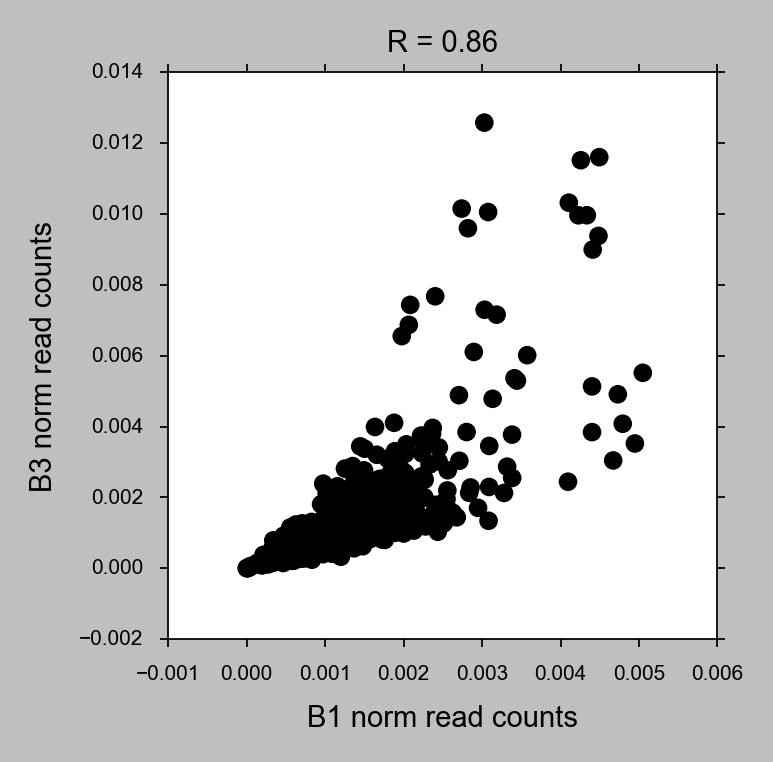

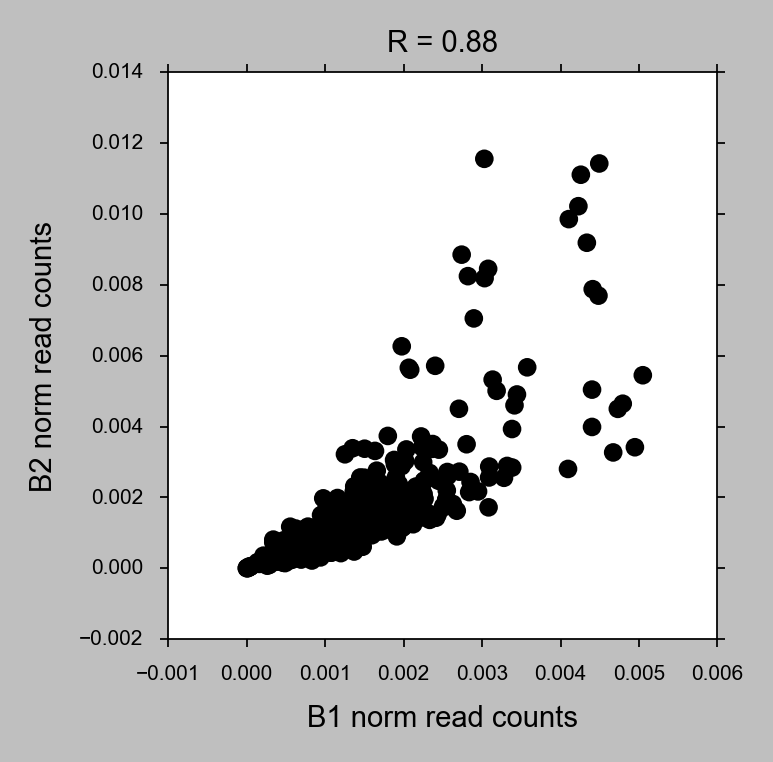

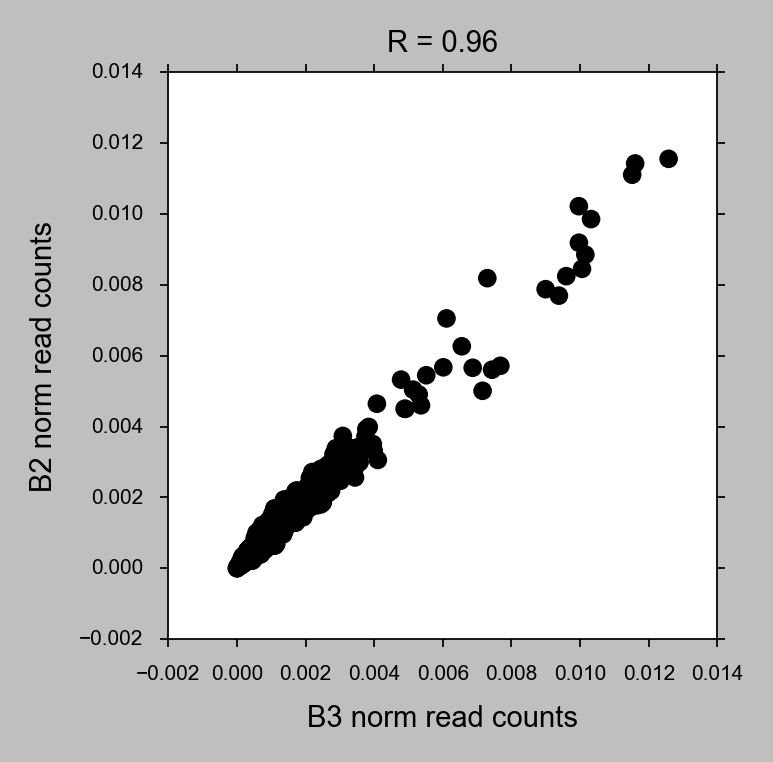

In [11]:
from scipy.stats import spearmanr

for (k1, df1), (k2, df2) in itertools.combinations(normalized_epi_bulk_count_df_dict.items(), 2):
    merged_df = df1.merge(df2, on="reference_name", suffixes=("_x", "_y"))

    ax, fig, gs = startfig(6, 6)

    ax.scatter(merged_df["read_count_x"], merged_df["read_count_y"], edgecolor="none", color="black")

    ax.set_xlabel(f"B{k1.split('_')[1]} norm read counts", fontsize=7)
    ax.set_ylabel(f"B{k2.split('_')[1]} norm read counts", fontsize=7)

    res = spearmanr(merged_df["read_count_x"], merged_df["read_count_y"])
    ax.set_title(f"R = {round(res.statistic, 2)}", fontsize=7)

    ax.tick_params("both", labelsize=5)

In [ ]:
bulk_project_dir = project_dir / "bulk_seq_data" / "tcr" 
name_split_location = 2

In [ ]:
for count_file in (bulk_project_dir / "counts").glob("*.csv"):
    print(count_file.name)
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file="/references/mel-pt-b_nsclc-pt-c_beta.fa",
        library_ref_id_list=["Mel-Pt-B"],
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True,
        percentile_ratio_filter_threshold = 1,
        xlabel="Number of reads per transcript",
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=25,
        w=6.25,
        h=6.25,
    )
    print("\n")

In [ ]:
tcr_count_dir = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts"
normalized_tcr_bulk_count_df_dict = dict()

for count_file in tcr_count_dir.glob("*.csv"):
    print(count_file)
    tcr_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name")
    normalized_tcr_bulk_count_df_dict[count_file.stem] = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df, count_col="read_count")


count_files_list = list(normalized_tcr_bulk_count_df_dict.keys())
normalized_tcr_bulk_counts_df = normalized_tcr_bulk_count_df_dict[count_files_list[0]].copy()
for count_file in count_files_list[1:]:
    normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df.merge(
        normalized_tcr_bulk_count_df_dict[count_file], on="reference_name", how="inner", suffixes=("", f"_{count_file.split('_')[2]}")
    )

normalized_tcr_bulk_counts_df.loc[:, "read_count"] = normalized_tcr_bulk_counts_df.loc[:, ["read_count", "read_count_T1", "read_count_T2"]].mean(1)
normalized_tcr_bulk_counts_df.drop(["read_count_T1", "read_count_T2"], axis=1, inplace=True)

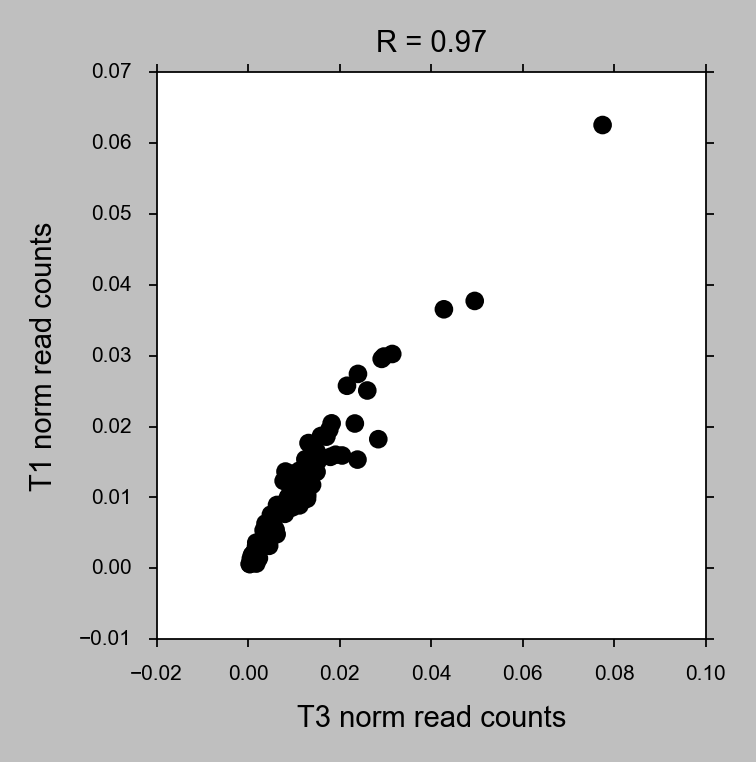

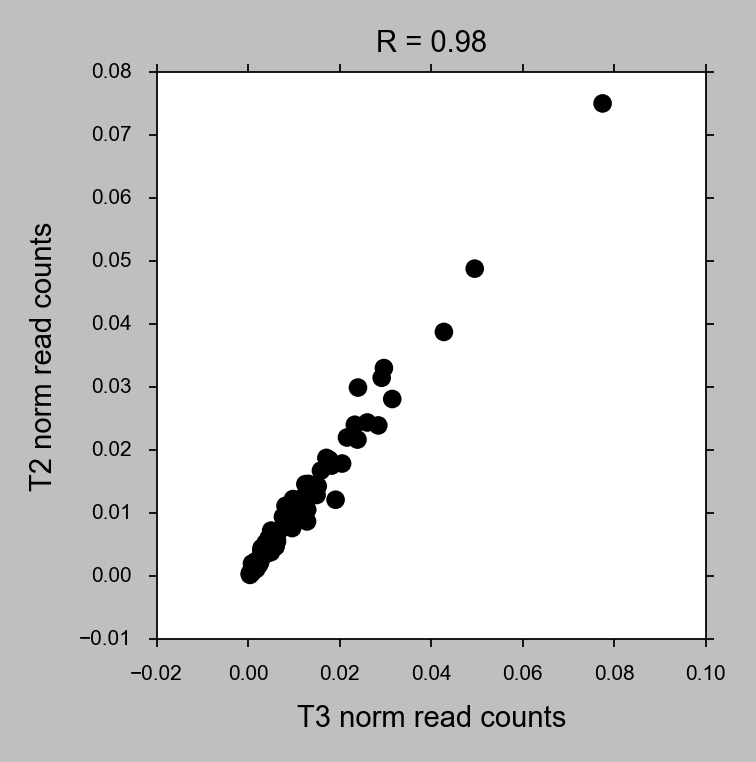

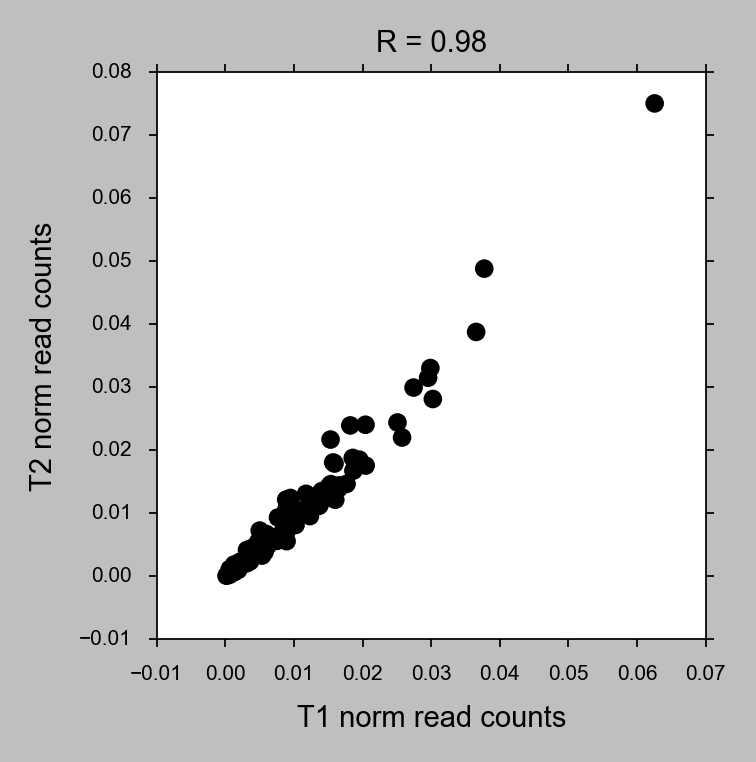

In [13]:
from scipy.stats import spearmanr

for (k1, df1), (k2, df2) in itertools.combinations(normalized_tcr_bulk_count_df_dict.items(), 2):
    merged_df = df1.merge(df2, on="reference_name", suffixes=("_x", "_y"))

    ax, fig, gs = startfig(6, 6)

    ax.scatter(merged_df["read_count_x"], merged_df["read_count_y"], edgecolor="none", color="black")

    ax.set_xlabel(f"{k1.split('_')[2]} norm read counts", fontsize=7)
    ax.set_ylabel(f"{k2.split('_')[2]} norm read counts", fontsize=7)

    res = spearmanr(merged_df["read_count_x"], merged_df["read_count_y"])
    ax.set_title(f"R = {round(res.statistic, 2)}", fontsize=7)

    ax.tick_params("both", labelsize=5)

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts" / "8191_39_T-mel-pt-b_CTACGACA-TTGGACTC_S39_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name")
normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df_2, count_col="read_count")

In [ ]:
normalized_tcr_bulk_counts_df.index.name = "reference_name"
tcr_merged_df = normalized_tcr_bulk_counts_df.merge(normalized_tcr_bulk_counts_df_2, on="reference_name", how="inner", suffixes=("_r1", "_r2"))

ax, fig, gs = startfig(6, 6)

ax.scatter(tcr_merged_df.loc[:, "read_count_r1"], tcr_merged_df.loc[:, "read_count_r2"], edgecolor="none", color="black")

ax.set_xlabel("Mel-Pt-B TCR norm read counts May", fontsize=7)
ax.set_ylabel("Average Mel-Pt-B TCR norm read counts Aug", fontsize=7)
res = spearmanr(tcr_merged_df.loc[:, "read_count_r1"], tcr_merged_df.loc[:, "read_count_r2"])
ax.set_title(round(res.statistic, 2), fontsize=7)
ax.tick_params("both", labelsize=7)

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "epi" / "counts" / "8191_35_B-mel-pt-b_GACCTGAA-CTCACCAA_S35_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
epi_bulk_counts_df_2 = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
normalized_epi_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df_2, count_col="read_count")

In [ ]:
normalized_epi_bulk_counts_df.index.name = "reference_name"
epi_merged_df = normalized_epi_bulk_counts_df.merge(normalized_epi_bulk_counts_df_2, on="reference_name", how="inner", suffixes=("_r1", "_r2"))

ax, fig, gs = startfig(6, 6)

ax.scatter(epi_merged_df.loc[:, "read_count_r1"], epi_merged_df.loc[:, "read_count_r2"], edgecolor="none", color="black")

ax.set_xlabel("Mel-Pt-B Ag norm read counts May", fontsize=7)
ax.set_ylabel("Average Mel-Pt-B Ag norm read counts Aug", fontsize=7)
res = spearmanr(epi_merged_df.loc[:, "read_count_r1"], epi_merged_df.loc[:, "read_count_r2"])
ax.set_title(round(res.statistic, 2), fontsize=7)
ax.tick_params("both", labelsize=7)

### Mel-Pt-B PAIR-Scan analysis 

In [ ]:
# After individual TCR-Ag pair validation co-cultures, code can be re-run with a validating_pair_dict to color annotate dots in results plots. 
validating_pair_dict = {
    "epi_mel-pt-b_PGAP6_A52V_182-tcr_1_2_B19_42_mel-pt-b_34": True, 
    "epi_mel-pt-b_BUB1B_L575F_188-tcr_1_2_D14_85_mel-pt-b_77": True,
    "epi_mel-pt-b_BBS12_E612Q_432-tcr_1_2_E4_99_mel-pt-b_91": True, 
    "epi_mel-pt-b_BBS12_E612Q_432-tcr_1_2_A23_22_mel-pt-b_14": True,
    "epi_mel-pt-b_PSMA6_S17L_47-tcr_1_2_C16_63_mel-pt-b_55": True, 
    "epi_mel-pt-b_NBEA_D230N_76-tcr_1_2_D7_78_mel-pt-b_70": False, 

    "epi_mel-pt-b_BICRAL_S805F_339-tcr_1_2_C19_66_mel-pt-b_58": False, 
    "epi_mel-pt-b_OBSCN_E2657K_324-tcr_1_2_C7_54_mel-pt-b_46": False, 
    "epi_mel-pt-b_PKHD1L1_G3255E_508-tcr_1_2_B24_47_mel-pt-b_39": False, 
    "epi_mel-pt-b_PGM2_P507L_252-tcr_1_2_D22_93_mel-pt-b_85": False, 
    "epi_mel-pt-b_EFEMP2_E317DTNRCVE_95-tcr_1_2_D2_73_mel-pt-b_65": False, 
    "epi_mel-pt-b_CDH17_R263W_741-tcr_1_2_D19_90_mel-pt-b_82": False, 
    "epi_mel-pt-b_PIK3CB_D988E_181-tcr_1_2_D8_79_mel-pt-b_71": False, 
    "epi_mel-pt-b_FLT3_296fs_661-tcr_1_2_D20_91_mel-pt-b_83": False, 
    "epi_mel-pt-b_PTPRO_S934F_293-tcr_1_2_D6_77_mel-pt-b_69": False, 
    "epi_mel-pt-b_CSMD2_E1112D_739-tcr_1_2_A12_11_mel-pt-b_3": False, 
    "epi_mel-pt-b_KCNQ5_L302F_627-tcr_1_2_A17_16_mel-pt-b_8": False,

    "epi_mel-pt-b_VIPAS39_R221Q_93-tcr_1_2_B20_43_mel-pt-b_35": False, # B cell reactive
    "epi_mel-pt-b_SCN2A_G266E_489-tcr_1_2_A20_19_mel-pt-b_11": False
    
    
    }

In [24]:
counts_df_dict = read_umi_count_tsv(project_dir=project_dir, plate_name_split_location=2)

Reading plate: 2-39
Reading plate: 36
Reading plate: 35
Reading plate: 2-8
Reading plate: 2-10
Reading plate: 32
Reading plate: 2-3
Reading plate: 2-7
Reading plate: 38
Reading plate: 30
Reading plate: 2-12
Reading plate: 34
Reading plate: 2-4
Reading plate: 2-2
Reading plate: 2-6
Reading plate: 29
Reading plate: 44
Reading plate: 2-11
Reading plate: 2-5
Reading plate: 2-1


In [ ]:
epi_umi_threshold_dict = {"2-39": 40, 
                          "36": 200, 
                          "35": 200, 
                          "2-8": 80,   
                          "2-10": 70,
                          "32": 250, 
                          "2-3": 125, 
                          "2-7": 60, 
                          "38": 200, 
                          "30": 200, 
                          "2-12": 50, 
                          "34": 50, 
                          "2-4": 50, 
                          "2-2": 50,
                          "2-6": 75, 
                          "29": 200, 
                          "44": 200, 
                          "2-11": 50, 
                          "2-5": 50, 
                          "2-1": 90,  
                          }

tcr_umi_threshold_dict = {"2-39": 40,
                          "36": 15, 
                          "35": 7, 
                          "2-8": 30, 
                          "2-10": 20,
                          "32": 60, 
                          "2-3": 50, 
                          "2-7": 50, 
                          "38": 60, 
                          "30": 40, 
                          "2-12": 40, 
                          "34": 15, 
                          "2-4": 50, 
                          "2-2": 50,
                          "2-6": 60, 
                          "29": 20,  
                          "44": 100, 
                          "2-11": 30, 
                          "2-5": 40, 
                          "2-1": 70, 
                          }


In [ ]:
counts_df_dict = filter_UMI_counts_df_dict(
    project_dir = project_dir, 
    counts_df_dict = counts_df_dict, 
    epi_umi_threshold=epi_umi_threshold_dict, 
    tcr_umi_threshold=tcr_umi_threshold_dict,
    min_start_fraction_of_top_umi_count=1.4,
    min_end_fraction_of_top_umi_count = 0.13, 
    num_bins=50
)

Filtering plate: 2-39
Number of unique epis: 493
Number of unique tcrs: 65
Filtering plate: 36
Number of unique epis: 421
Number of unique tcrs: 74
Filtering plate: 35
Number of unique epis: 372
Number of unique tcrs: 77
Filtering plate: 2-8
Number of unique epis: 250
Number of unique tcrs: 59
Filtering plate: 2-10
Number of unique epis: 429
Number of unique tcrs: 73
Filtering plate: 32
Number of unique epis: 330
Number of unique tcrs: 64
Filtering plate: 2-3
Number of unique epis: 201
Number of unique tcrs: 46
Filtering plate: 2-7
Number of unique epis: 318
Number of unique tcrs: 61
Filtering plate: 38
Number of unique epis: 350
Number of unique tcrs: 55
Filtering plate: 30
Number of unique epis: 318
Number of unique tcrs: 72
Filtering plate: 2-12
Number of unique epis: 467
Number of unique tcrs: 60
Filtering plate: 34
Number of unique epis: 563
Number of unique tcrs: 73
Filtering plate: 2-4
Number of unique epis: 96
Number of unique tcrs: 23
Filtering plate: 2-2
Number of unique epis

In [27]:
plot_detected_tcr_epi_plate_map(
    project_dir=project_dir, counts_df_dict=counts_df_dict, validating_pair_dict=validating_pair_dict, epitope_barcode_length=18, detected_fontsize=3
)

Plotting plate: 2-39
Plotting plate: 36
Plotting plate: 35
Plotting plate: 2-8
Plotting plate: 2-10
Plotting plate: 32
Plotting plate: 2-3
Plotting plate: 2-7
Plotting plate: 38
Plotting plate: 30
Plotting plate: 2-12
Plotting plate: 34
Plotting plate: 2-4
Plotting plate: 2-2
Plotting plate: 2-6
Plotting plate: 29
Plotting plate: 44
Plotting plate: 2-11
Plotting plate: 2-5
Plotting plate: 2-1


In [ ]:
plates_list_name = "mel-pt-b"

In [ ]:
plates_list = ["29", "30", "32", "34", "35", "36", "38", "44", "2-1", "2-2", "2-3", "2-4", "2-5", "2-6", "2-7", "2-8", "2-10", "2-11", "2-12", "2-39"]

write_tcr_epi_pair_well_count_files(
    project_dir=project_dir,
    plates_list=plates_list,
    plates_list_name=plates_list_name,
    counts_df_dict=counts_df_dict.copy(),
    collapse_epitope_barcode=True,
    epitope_barcode_length=18,
    validating_pair_dict=validating_pair_dict,
)

Processing plate: 29
Processing plate: 30
Processing plate: 32
Processing plate: 34
Processing plate: 35
Processing plate: 36
Processing plate: 38
Processing plate: 44
Processing plate: 2-1
Processing plate: 2-2
Processing plate: 2-3
Processing plate: 2-4
Processing plate: 2-5
Processing plate: 2-6
Processing plate: 2-7
Processing plate: 2-8
Processing plate: 2-10
Processing plate: 2-11
Processing plate: 2-12
Processing plate: 2-39
Writing Mel-Pt-B-r1-r2 summary statistics...
Total # of co-culture sort wells counted: 6116


In [ ]:
weights = [2731, 3385]
tcr_merged_df.loc[:, "read_count"] = tcr_merged_df.loc[:, ["read_count_r1", "read_count_r2"]].dot(weights) / sum(weights)
epi_merged_df.loc[:, "read_count"] = epi_merged_df.loc[:, ["read_count_r1", "read_count_r2"]].dot(weights) / sum(weights)

In [31]:
print(sum(weights))

6116


In [32]:
pair_count_matrix_df = read_tcr_epi_pair_counts_csv(pair_count_matrix_csv=Path(project_dir) / "outs" / plates_list_name / f"pair_count_matrix_df_{plates_list_name}.csv")
exp_pair_prob_matrix_df, pair_count_matrix_df = calculate_tcr_epi_pair_exp_prob_matrix(
    pair_count_matrix_df=pair_count_matrix_df,
    normalized_epitope_bulk_counts_df=epi_merged_df,
    normalized_tcr_bulk_counts_df=tcr_merged_df,
    bulk_epitope_count_col="read_count",
    bulk_tcr_count_col="read_count",
    normalize_using_plate=False,
)

Total called TCR-epitope pair counts: 7331.0
Calculating expected TCR-epitope pair probability matrix using TCR and epitope gDNA bulk sequencing data...
Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!
Epitope reference name(s) in normalized_epitope_bulk_counts_df that are missing in pair_count_matrix_df: {'epi_Mel-Pt-B_GUCY1A2_K165RLK_567', 'epi_Mel-Pt-B_CARNMT1_201fs_313', 'epi_Mel-Pt-B_SETSIP_S175F_771', 'epi_Mel-Pt-B_ACACB_P474S_192', 'epi_Mel-Pt-B_NELL2_C391F_266', 'epi_Mel-Pt-B_B4GALNT1_E252K_727', 'epi_Mel-Pt-B_EIF3D_A47T_68', 'epi_Mel-Pt-B_UGGT2_T1217I_187', 'epi_Mel-Pt-B_LVRN_P350L_570', 'epi_Mel-Pt-B_FRMD1_G373S_745', 'epi_Mel-Pt-B_TMPRSS2_E91K_757', 'epi_Mel-Pt-B_PKP2_E728K_680', 'epi_Mel-Pt-B_ASAP1_T372A_42', 'epi_Mel-Pt-B_FAT4_G2316E_526', 'epi_Mel-Pt-B_EFCAB7_S244F_354', 'epi_Mel-Pt-B_DTHD1_S544L_381', 'epi_Mel-Pt-B_TEF_R234L_470', 'epi_Mel-Pt-B_ENSG00000289700_P164F_776',

In [33]:
alpha = 0.0005
pair_fold_changes_df = obs_tcr_epi_count_binom_sf_test(
    project_dir=project_dir,
    pair_count_matrix_df=pair_count_matrix_df,
    exp_pair_prob_matrix_df=exp_pair_prob_matrix_df,
    plates_list_name=plates_list_name,
    validating_pair_dict = validating_pair_dict,
    fdr_correction=True,
    alpha=alpha,
    normalize_total_called_pairs=False,
    normalize_total_wells_with_detected_pair=True,
    sort_fold_change=False,
    sort_pvalue=True,
)

6029 TCR-epitope pairs have non-zero well counts of 70680 tested TCR-epitope pairs


In [34]:
pair_fold_changes_df = add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col(
    project_dir=project_dir, 
    plates_list_name=plates_list_name, 
    pair_fold_changes_df=pair_fold_changes_df, 
    epi_transcript_ratio=0.35, tcr_transcript_ratio=0.35
)

In [35]:
pair_fold_changes_df = add_pair_entropy_over_plate_col(pair_fold_changes_df = pair_fold_changes_df, project_dir = project_dir)

In [36]:
write_reactive_pair_results(
    pair_fold_changes_df=pair_fold_changes_df,
    project_dir=project_dir,
    plates_list_name=plates_list_name,
    validating_pair_dict = validating_pair_dict
)

In [37]:
pair_fold_changes_df.to_excel(Path(project_dir) / "outs" / plates_list_name / f"pair_fold_changes_df_{plates_list_name}.xlsx")

In [43]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(
    pair_fold_changes_df=pair_fold_changes_df,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    title=plates_list_name,
    xlim_max=80,
    xlim_min=-5,
    ylim_max=30,
    ylim_min=-2.5,
    adj_pval_alpha=None,
    filter_significant_with_more_than_one_epi=True,
    custom_pair_color_dict=None,
    annotate=True,
)

In [44]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(
    pair_fold_changes_df=pair_fold_changes_df,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    title=plates_list_name,
    xlim_max=80,
    xlim_min=-5,
    ylim_max=30,
    ylim_min=-2.5,
    adj_pval_alpha=None,
    filter_significant_with_more_than_one_epi=True,
    custom_pair_color_dict=None,
    annotate=False,
)